In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv('stars_class.csv', index_col=0, delimiter=';')
df.head()

,alpha,delta,u,g,r,i,z,run_ID,cam_col,field_ID,redshift,plate,MJD,fiber_ID
class,,,,,,,,,,,,,,
GALAXY,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,2,79,0.634794,5812,56354,171
GALAXY,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,5,119,0.779136,10445,58158,427
GALAXY,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,2,120,0.644195,4576,55592,299
GALAXY,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,3,214,0.932346,9149,58039,775
GALAXY,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,3,137,0.116123,6121,56187,842


In [24]:
#PASSO A PASSO PARA AUTO-ESCALAR OS DAODS
#1- CALCULANDO A MEDIA DE CADA VARIAVEL
dfm = df.mean()

#2- CALCULANDO O DESVIO PADRAO DE CADA VARIAVEL
dfpd = df.std()

#3- AUTO-ESCALANDO OS DADOS
dfauto = (df - dfm) / dfpd

dfauto.head()

##############
# from sklearn.preprocessing import StandardScaler
# scale_obj = StandardScaler()
# dfauto = scale_obj.fit_transform(dfauto.astype(float))
# display(dfauto)

,alpha,delta,u,g,r,i,z,run_ID,cam_col,field_ID,redshift,plate,MJD,fiber_ID
class,,,,,,,,,,,,,,
GALAXY,-0.459995,0.662586,0.699546,0.725153,0.340389,0.025944,0.024863,-0.622773,-1.098286,-0.834035,0.048627,0.193067,0.383573,-1.023423
GALAXY,-0.377115,0.589086,1.121884,1.012279,1.544918,1.214224,1.662508,-0.199827,1.279223,-0.497493,0.246132,1.798778,1.408539,-0.070076
GALAXY,-0.401037,0.848548,1.350014,0.925617,0.458535,0.134447,0.114602,-0.622773,-1.098286,-0.489080,0.061491,-0.235307,-0.049367,-0.546750
GALAXY,1.381862,-1.318641,-0.119030,1.499618,1.009715,0.820435,0.289847,-0.351011,-0.305783,0.301792,0.455771,1.349609,1.340928,1.225880
GALAXY,1.441199,-0.018597,-1.387608,-1.696898,-1.803868,-1.866280,-1.861597,1.462280,-0.305783,-0.346050,-0.661075,0.300161,0.288690,1.475389


In [25]:
#CALCULO DA MATRIZ DE CORRELACOES
corr = dfauto.iloc[:,0:17].corr()
corr

,alpha,delta,u,g,r,i,z,run_ID,cam_col,field_ID,redshift,plate,MJD,fiber_ID
alpha,1.000000,0.014482,-0.011099,-0.034727,-0.042558,-0.045243,-0.042351,0.178344,0.066293,-0.408621,-0.019429,-0.051404,-0.027850,-0.005645
delta,0.014482,1.000000,-0.069214,-0.087917,-0.102865,-0.131325,-0.124173,-0.381335,0.003555,-0.271581,-0.124927,-0.071662,-0.086584,-0.007247
u,-0.011099,-0.069214,1.000000,0.805054,0.660865,0.561069,0.488374,0.151886,-0.095792,-0.048131,0.113362,0.322848,0.370979,0.162977
g,-0.034727,-0.087917,0.805054,1.000000,0.932146,0.843307,0.772338,0.171281,-0.048286,0.016294,0.312563,0.582159,0.606228,0.186732
r,-0.042558,-0.102865,0.660865,0.932146,1.000000,0.953380,0.919626,0.181755,-0.022535,0.075525,0.426990,0.673197,0.680975,0.159611
i,-0.045243,-0.131325,0.561069,0.843307,0.953380,1.000000,0.967970,0.184969,-0.026011,0.131492,0.501819,0.680937,0.683457,0.142705
z,-0.042351,-0.124173,0.488374,0.772338,0.919626,0.967970,1.000000,0.177294,-0.029598,0.142782,0.512538,0.685904,0.687435,0.153055
run_ID,0.178344,-0.381335,0.151886,0.171281,0.181755,0.184969,0.177294,1.000000,-0.067904,0.179640,0.114803,0.343968,0.371654,0.106058
cam_col,0.066293,0.003555,-0.095792,-0.048286,-0.022535,-0.026011,-0.029598,-0.067904,1.000000,-0.042158,-0.015587,-0.030254,-0.044614,0.062084
field_ID,-0.408621,-0.271581,-0.048131,0.016294,0.075525,0.131492,0.142782,0.179640,-0.042158,1.000000,0.144678,0.160859,0.134168,-0.020750


<Axes: >

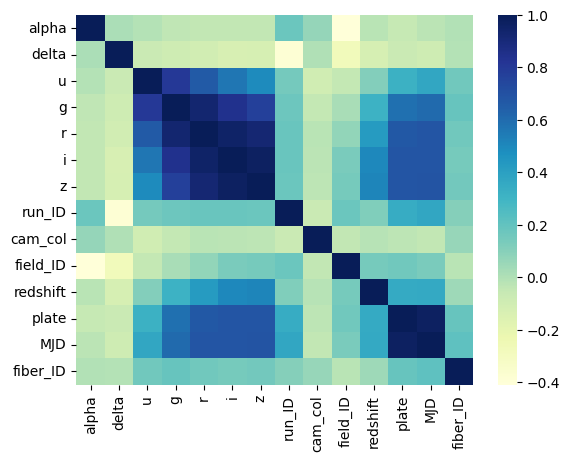

In [26]:
sns.heatmap(corr,
            xticklabels=corr.columns,
            yticklabels=corr.columns, cmap='YlGnBu')

In [27]:
#ANALISE DE COMPONENTES PRINCIPAIS
# DECOMPONDOA A MATRIZ DE VARIANCIAS E COVARIANCIAS EM COMPONENETES PRINCIPAIS

X = np.asarray(dfauto.iloc[:,0:16])
S = np.cov(X)

In [28]:
X

array([[-0.45999508,  0.66258627,  0.69954644, ...,  0.19306709,
         0.38357342, -1.0234231 ],
       [-0.37711463,  0.5890857 ,  1.1218841 , ...,  1.79877775,
         1.40853904, -0.07007604],
       [-0.40103733,  0.84854764,  1.35001419, ..., -0.23530727,
        -0.0493666 , -0.54674957],
       ...,
       [-0.20065462,  1.88047699,  0.86926719, ...,  0.50291068,
         0.40118647,  0.90561508],
       [-0.15238035,  1.92053256, -1.0452954 , ..., -1.47052264,
        -1.7214696 , -1.12769543],
       [-0.13326086,  2.27933965, -0.14242221, ...,  0.63911708,
         0.56084021,  0.28370509]])

In [29]:
#VARIANCAS DE CADA VARIAVEL
np.diagonal(X)

array([-0.45999508,  0.5890857 ,  1.35001419,  1.49961765, -1.80386753,
        0.67303275,  0.97242952,  1.30970412,  1.27922292, -0.47225266,
       -0.19109741, -0.18297351,  0.4892517 , -0.91542675])

In [30]:
from sklearn.decomposition import PCA
pca = PCA(n_components=10)

In [31]:
pca.fit(X)
pca.components_
# pca.components_.shape
# pca.components_[2,:]

array([[-0.02236732, -0.07352569,  0.27246647,  0.37294506,  0.398917  ,
         0.39583821,  0.3862694 ,  0.13605709, -0.02382736,  0.06717635,
         0.21320289,  0.34162772,  0.34743988,  0.09627872],
       [-0.32894973, -0.47418108, -0.24310087, -0.19062131, -0.12179285,
        -0.0556761 , -0.03185008,  0.35014898, -0.08282766,  0.61900306,
         0.13179789,  0.10256212,  0.08681195, -0.06713118],
       [ 0.64582557, -0.30766996, -0.03168689, -0.06950164, -0.08582578,
        -0.09173162, -0.08881458,  0.57395568,  0.08650106, -0.27170043,
        -0.06061322,  0.08905354,  0.11991496,  0.14843327],
       [ 0.01624602,  0.25178542, -0.44103327, -0.20787957, -0.05878722,
         0.01439302,  0.06862335, -0.13499267,  0.65664085,  0.01812251,
         0.27583064,  0.24791942,  0.21298912,  0.24000843],
       [-0.28704114, -0.01142729,  0.25134321,  0.10073997, -0.03187118,
        -0.11469759, -0.13707032,  0.07465682,  0.14503366,  0.09676919,
        -0.45241356,  0.00

In [32]:
#VARIANCIA DOS COMPONENTES PRINCIPAIS
pca.explained_variance_ratio_
np.round(pca.explained_variance_ratio_, 2)

array([0.41, 0.11, 0.1 , 0.08, 0.07, 0.07, 0.06, 0.04, 0.03, 0.02])

In [33]:
pca.explained_variance_ratio_.cumsum()

# Se trazermos os primeiros 6 PCAs chegamos em 0.83
# Com 6 variaveis substituo 13

array([0.40664836, 0.52027858, 0.61619573, 0.69362647, 0.76677426,
       0.83659849, 0.89309967, 0.92989921, 0.96296454, 0.98714283])

Text(0, 0.5, 'Eigenvalue')

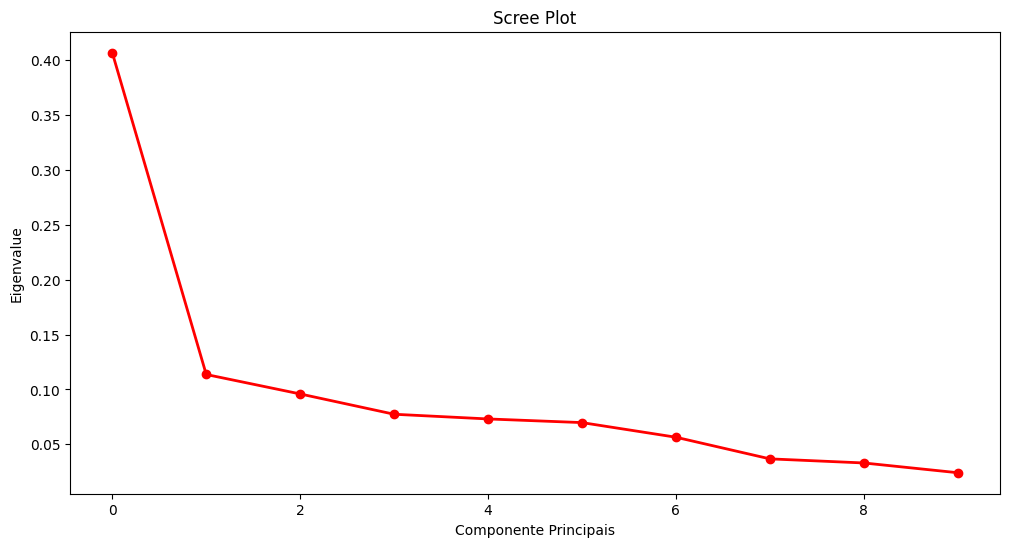

In [34]:
fig = plt.figure(figsize=(12, 6))

plt.plot(pca.explained_variance_ratio_, 'ro-', linewidth=2)
plt.title('Scree Plot')
plt.xlabel('Componente Principais')
plt.ylabel('Eigenvalue')

In [35]:
pca.transform(X)

array([[ 0.5747458 , -1.03000605, -0.92481018, ..., -0.38605016,
        -0.58900096,  0.31691339],
       [ 3.4459647 , -1.06965421, -0.48742613, ..., -0.35361894,
        -0.27777331,  0.01136052],
       [ 0.71153417, -1.25550577, -1.12036973, ...,  0.26210954,
        -0.48846996,  0.34926499],
       ...,
       [ 0.67332242, -1.72728666, -1.09686962, ...,  0.3622901 ,
         0.01191355,  0.4376241 ],
       [-3.80070725, -0.8600752 , -1.29030622, ...,  0.73167726,
         0.06608066, -0.50641621],
       [-1.20404792, -0.55370887, -1.26014924, ...,  1.02445765,
         0.38453617,  1.23961534]])

In [36]:
pca_6 = PCA(n_components=6)
pca_6.fit(X)
pca_6.components_

array([[-0.02236732, -0.07352569,  0.27246647,  0.37294506,  0.398917  ,
         0.39583821,  0.3862694 ,  0.13605709, -0.02382736,  0.06717635,
         0.21320289,  0.34162772,  0.34743988,  0.09627872],
       [-0.32894973, -0.47418108, -0.24310087, -0.19062131, -0.12179285,
        -0.0556761 , -0.03185008,  0.35014898, -0.08282766,  0.61900306,
         0.13179789,  0.10256212,  0.08681195, -0.06713118],
       [ 0.64582557, -0.30766996, -0.03168689, -0.06950164, -0.08582578,
        -0.09173162, -0.08881458,  0.57395568,  0.08650106, -0.27170043,
        -0.06061322,  0.08905354,  0.11991496,  0.14843327],
       [ 0.01624602,  0.25178542, -0.44103327, -0.20787957, -0.05878722,
         0.01439302,  0.06862335, -0.13499267,  0.65664085,  0.01812251,
         0.27583064,  0.24791942,  0.21298912,  0.24000843],
       [-0.28704114, -0.01142729,  0.25134321,  0.10073997, -0.03187118,
        -0.11469759, -0.13707032,  0.07465682,  0.14503366,  0.09676919,
        -0.45241356,  0.00

In [37]:
np.round(pca_6.components_[0],3)

array([-0.022, -0.074,  0.272,  0.373,  0.399,  0.396,  0.386,  0.136,
       -0.024,  0.067,  0.213,  0.342,  0.347,  0.096])

In [38]:
PCA1 = pca_6.transform(X)[:,0]
PCA2 = pca_6.transform(X)[:,1]
PCA3 = pca_6.transform(X)[:,2]
PCA4 = pca_6.transform(X)[:,3]
PCALL = pca_6.transform(X)



In [39]:
df['PCA1'] = PCA1
df['PCA2'] = PCA2
df['PCA3'] = PCA3
df['PCA4'] = PCA4
df.head()

,alpha,delta,u,g,r,i,z,run_ID,cam_col,field_ID,redshift,plate,MJD,fiber_ID,PCA1,PCA2,PCA3,PCA4
class,,,,,,,,,,,,,,,,,,
GALAXY,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,2,79,0.634794,5812,56354,171,0.574746,-1.030006,-0.924810,-1.072722
GALAXY,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,5,119,0.779136,10445,58158,427,3.445965,-1.069654,-0.487426,1.132695
GALAXY,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,2,120,0.644195,4576,55592,299,0.711534,-1.255506,-1.120370,-1.426926
GALAXY,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,3,214,0.932346,9149,58039,775,2.554355,0.057736,1.135439,0.295730
GALAXY,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,3,137,0.116123,6121,56187,842,-2.832267,0.771239,2.817014,0.838103


In [40]:
df.sort_values(by='PCA1', ascending=False).head(50)

,alpha,delta,u,g,r,i,z,run_ID,cam_col,field_ID,redshift,plate,MJD,fiber_ID,PCA1,PCA2,PCA3,PCA4
class,,,,,,,,,,,,,,,,,,
QSO,8.637128,-1.127558,24.58678,24.46593,22.82553,21.62336,22.53122,4263,1,173,1.396341,9404,58045,894,4.564413,0.529346,-1.122467,-0.991903
GALAXY,40.497678,3.560161,23.20226,24.53431,23.82936,22.09652,22.75254,7718,2,259,0.530157,9416,58098,314,4.553135,1.299974,-0.542272,-1.176797
GALAXY,338.518632,-0.370662,24.36890,24.89395,23.60455,22.12098,22.23246,4192,3,212,0.734745,9217,57934,519,4.377726,-0.534290,0.598754,-0.528610
QSO,329.999623,3.726588,22.99822,22.15485,22.08356,22.02047,22.12553,7765,3,122,1.865205,11329,58426,1000,4.301447,0.201708,2.101963,1.014322
GALAXY,24.952626,2.378935,23.65257,23.76629,22.90933,22.02259,21.35769,7717,4,496,0.724460,9398,58124,764,4.256454,2.520094,-0.642313,0.319708
GALAXY,40.291114,3.586411,24.76180,23.50528,22.25379,21.97982,21.52896,7718,2,257,0.765215,9417,58055,624,4.077364,1.307323,-0.232915,-1.027704
GALAXY,134.281988,24.104792,23.40868,24.58809,22.48084,21.74477,21.81027,4576,4,148,1.605999,9598,58085,492,3.987905,-0.540263,-0.678714,0.902837
GALAXY,40.125506,3.504013,23.04723,22.91427,22.99111,22.17126,21.21337,7718,2,256,0.931355,9417,58055,584,3.914103,1.549012,-0.248205,-0.618247
QSO,341.502909,-0.308397,25.00198,23.11789,22.43975,21.29501,21.33819,4192,3,232,1.830383,9218,57724,842,3.871385,-0.110088,0.843090,0.206959


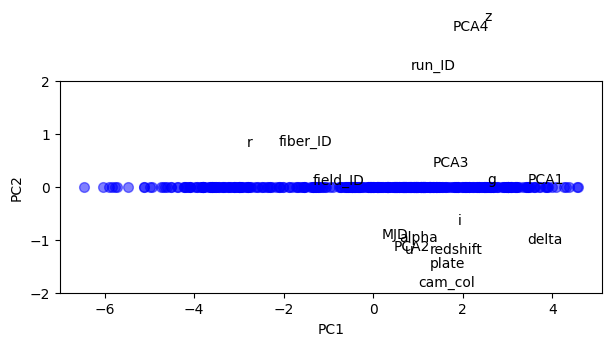

In [41]:
marker = dict(linestyle='none', marker='o', markersize=7, color='blue', alpha=0.5)
fix, ax = plt.subplots(figsize=(7, 2.75))
ax.plot(PCA1, np.zeros_like(PCA2), label="Scores", **marker)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
_ = ax.set_ylim(-2, 2)

text = [ax.text(x, y, t) for x, y, t in zip(PCA1, PCA2, df.columns)]

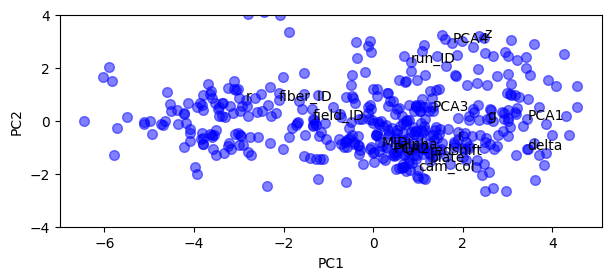

In [42]:
fix, ax = plt.subplots(figsize=(7, 2.75))
ax.plot(PCA1, PCA2, label="Scores", **marker)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
_ = ax.set_ylim(-4, 4)

text = [ax.text(x, y, t) for x, y, t in 
        zip(PCA1, PCA2, df.columns)]